In [1]:
pip install yfinance pandas

In [2]:
import yfinance as yf

ticker = yf.Ticker("GC=F")

df = ticker.history(start="2025-09-02", end="2026-09-02", interval="1d", auto_adjust=False)

df = df.drop(columns=['Dividends', 'Stock Splits'], errors='ignore')

df_display = df.reset_index()

display(df_display)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2025-09-02 00:00:00-04:00,3485.699951,3559.199951,3485.699951,3549.399902,3549.399902,658
1,2025-09-03 00:00:00-04:00,3554.800049,3593.699951,3553.199951,3593.199951,3593.199951,72
2,2025-09-04 00:00:00-04:00,3549.899902,3573.600098,3549.899902,3565.800049,3565.800049,237
3,2025-09-05 00:00:00-04:00,3567.800049,3613.199951,3567.800049,3613.199951,3613.199951,925
4,2025-09-08 00:00:00-04:00,3594.500000,3641.000000,3590.000000,3638.100098,3638.100098,97
...,...,...,...,...,...,...,...
247,2026-08-26 00:00:00-04:00,4615.299805,4615.299805,4598.200195,4598.200195,4598.200195,1051
248,2026-08-27 00:00:00-04:00,4609.700195,4609.700195,4609.700195,4609.700195,4609.700195,5558
249,2026-08-28 00:00:00-04:00,4599.299805,4625.500000,4451.799805,4478.100098,4478.100098,1758
250,2026-08-31 00:00:00-04:00,4430.000000,4466.899902,4410.899902,4431.100098,4431.100098,360


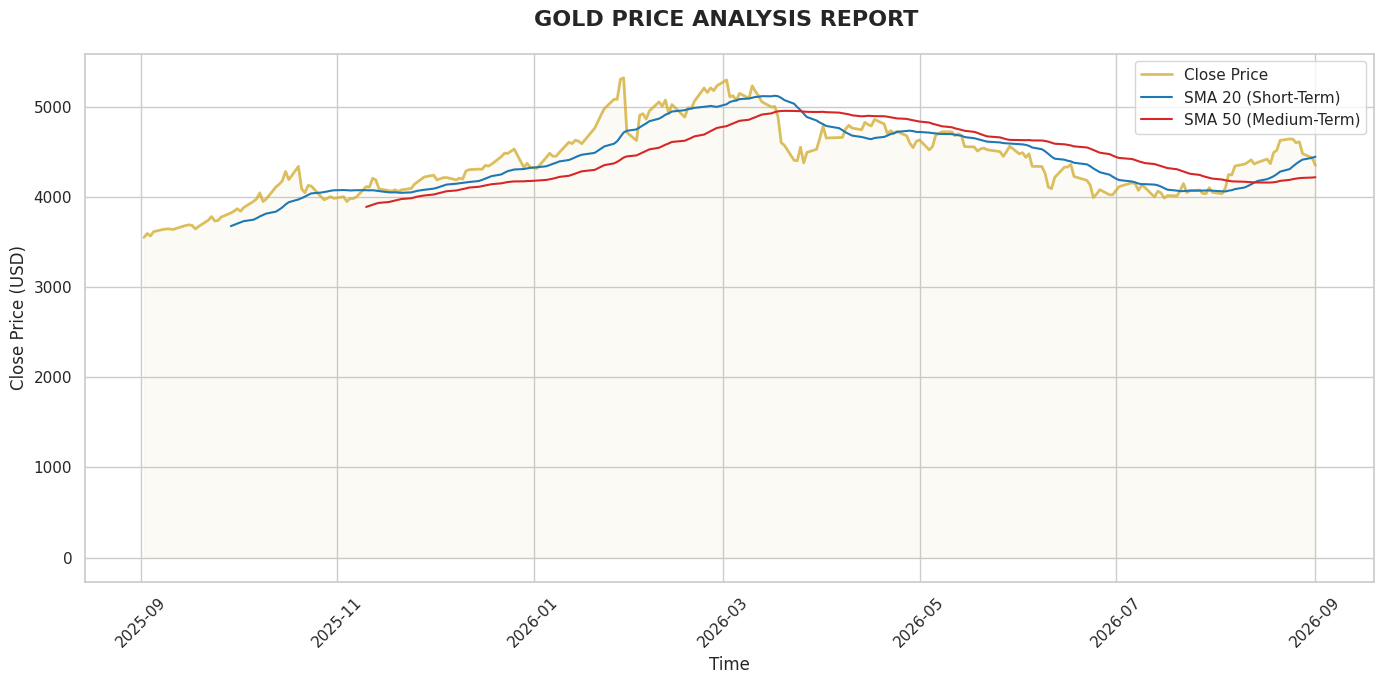

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()


sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

plt.plot(df.index, df['Close'], color='#d4af37', linewidth=2, label='Close Price', alpha=0.8)

plt.plot(df.index, df['SMA20'], color='#1f77b4', linewidth=1.5, label='SMA 20 (Short-Term)')
plt.plot(df.index, df['SMA50'], color='#d62728', linewidth=1.5, label='SMA 50 (Medium-Term)')

plt.fill_between(df.index, df['Close'], color='#d4af37', alpha=0.05)

plt.title('GOLD PRICE ANALYSIS REPORT ', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close Price (USD)', fontsize=12)

plt.xticks(rotation=45)
plt.legend()


plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print('Augmented Dickey-Fuller test results:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("\nKết luận: Chuỗi có tính dừng (Bác bỏ H0)")
    else:
        print("\nConclusion: The series is non-stationary (Accept H0). You need to take the difference.")

import pandas as pd
adf_test(df['Close'].dropna())

Augmented Dickey-Fuller test results:
Test Statistic                  -2.293079
p-value                          0.174210
#Lags Used                       0.000000
Number of Observations Used    251.000000
Critical Value (1%)             -3.456674
Critical Value (5%)             -2.873125
Critical Value (10%)            -2.572944
dtype: float64

Conclusion: The series is non-stationary (Accept H0). You need to take the difference.


--- ADF test for the first-differenced series ---
Augmented Dickey-Fuller test results:
Test Statistic                -1.234737e+01
p-value                        5.930535e-23
#Lags Used                     1.000000e+00
Number of Observations Used    2.490000e+02
Critical Value (1%)           -3.456888e+00
Critical Value (5%)           -2.873219e+00
Critical Value (10%)          -2.572994e+00
dtype: float64

Kết luận: Chuỗi có tính dừng (Bác bỏ H0)


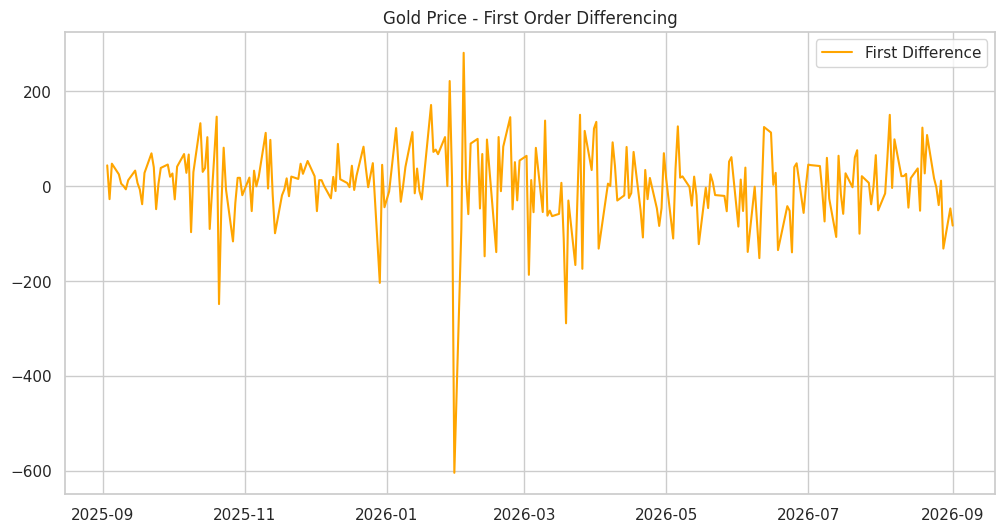

In [6]:

df['Close_diff'] = df['Close'].diff()

print("--- ADF test for the first-differenced series ---")
adf_test(df['Close_diff'].dropna())

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['Close_diff'], label='First Difference', color='orange')
plt.title('Gold Price - First Order Differencing')
plt.legend()
plt.show()

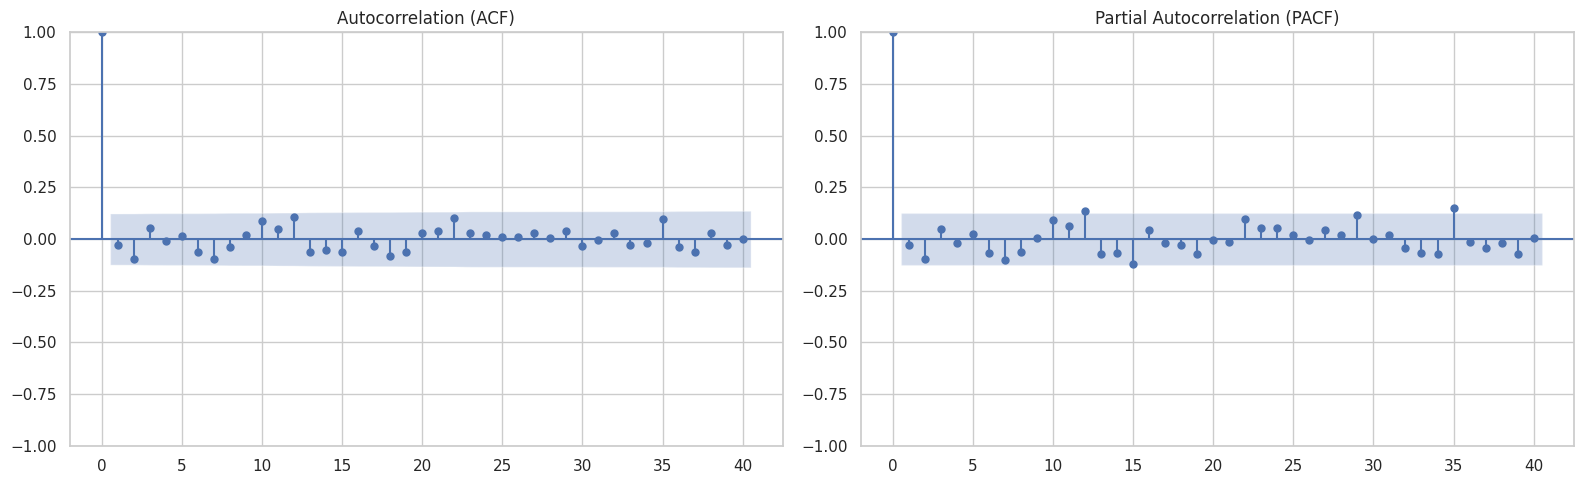

In [7]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['Close_diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(df['Close_diff'].dropna(), lags=40, ax=axes[1], method='yw')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [8]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

def evaluate_arima_models(dataset, p_values, d_value, q_values):
    best_score, best_cfg = float("inf"), None
    results = []

    for p in p_values:
        for q in q_values:
            order = (p, d_value, q)
            try:
                model = ARIMA(dataset, order=order)
                model_fit = model.fit()
                aic = model_fit.aic
                results.append((order, aic))
                if aic < best_score:
                    best_score, best_cfg = aic, order
                print(f'ARIMA{order} - AIC: {aic:.3f}')
            except:
                continue

    print(f'\n---> Best Model: ARIMA{best_cfg} with AIC = {best_score:.3f}')
    return best_cfg, results

p_range = range(0, 4) # Thử nghiệm p từ 0 đến 3
d_fixed = 1
q_range = range(0, 4) # Thử nghiệm q từ 0 đến 3

best_order, all_results = evaluate_arima_models(df['Close'], p_range, d_fixed, q_range)

ARIMA(0, 1, 0) - AIC: 2939.395
ARIMA(0, 1, 1) - AIC: 2941.156
ARIMA(0, 1, 2) - AIC: 2941.027
ARIMA(0, 1, 3) - AIC: 2942.167
ARIMA(1, 1, 0) - AIC: 2941.201
ARIMA(1, 1, 1) - AIC: 2942.350
ARIMA(1, 1, 2) - AIC: 2942.215
ARIMA(1, 1, 3) - AIC: 2944.138
ARIMA(2, 1, 0) - AIC: 2940.990
ARIMA(2, 1, 1) - AIC: 2942.153
ARIMA(2, 1, 2) - AIC: 2944.153
ARIMA(2, 1, 3) - AIC: 2942.643
ARIMA(3, 1, 0) - AIC: 2942.375
ARIMA(3, 1, 1) - AIC: 2944.153
ARIMA(3, 1, 2) - AIC: 2946.027
ARIMA(3, 1, 3) - AIC: 2940.073

---> Best Model: ARIMA(0, 1, 0) with AIC = 2939.395


In [9]:
final_model = ARIMA(df['Close'], order=best_order)
final_model_fit = final_model.fit()

print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  252
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1468.698
Date:                Sat, 05 Sep 2026   AIC                           2939.395
Time:                        13:25:43   BIC                           2942.920
Sample:                             0   HQIC                          2940.814
                                - 252                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7079.0336    252.612     28.023      0.000    6583.923    7574.144
Ljung-Box (L1) (Q):                   0.23   Jarque-Bera (JB):              1335.56
Prob(Q):                              0.63   Pr

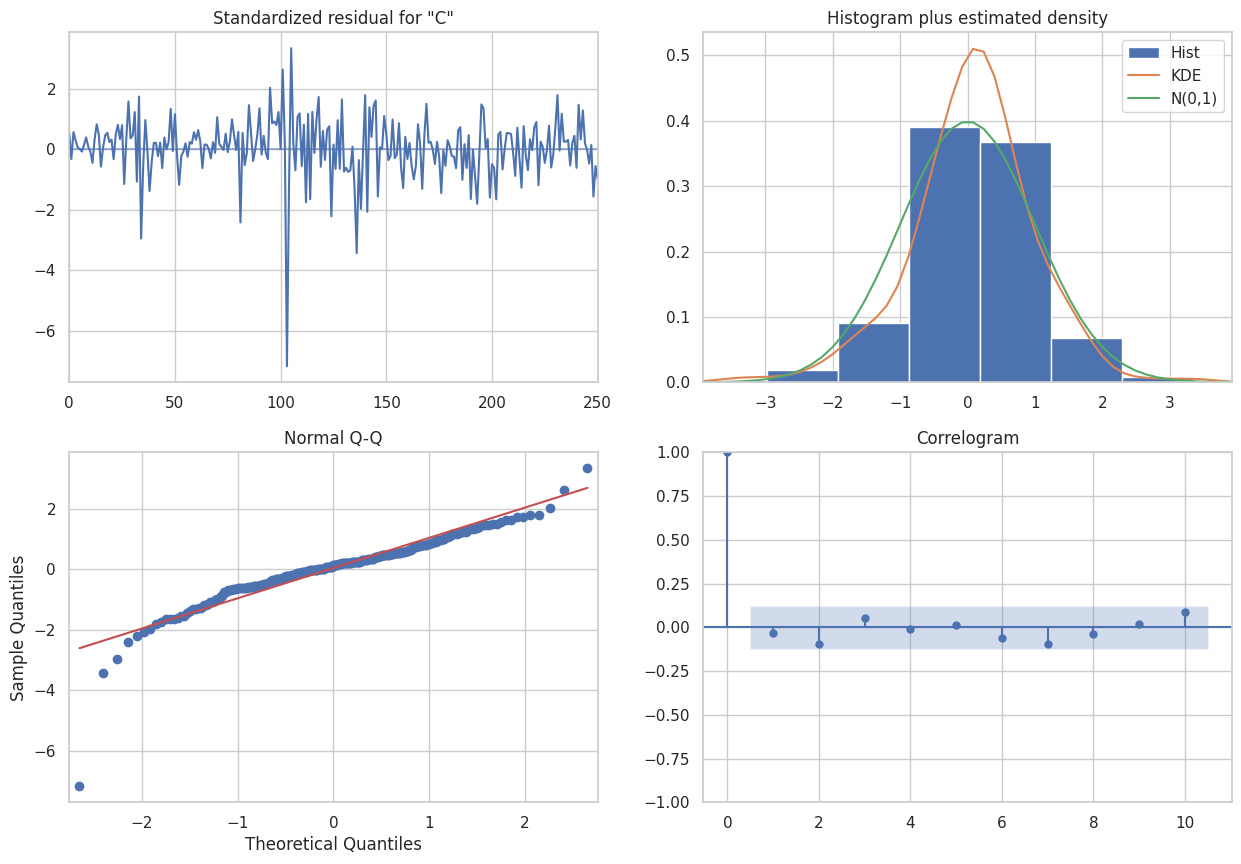

<Figure size 1000x400 with 0 Axes>

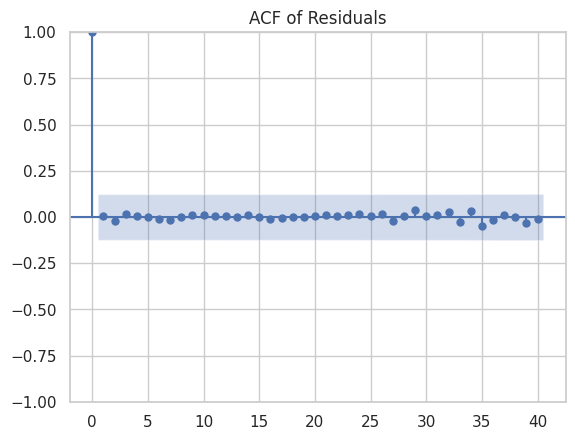

In [10]:
# Kiểm tra phần dư của mô hình
final_model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# Kiểm tra tự tương quan của phần dư
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(10, 4))
plot_acf(final_model_fit.resid, lags=40)
plt.title('ACF of Residuals')
plt.show()

In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error

predictions = final_model_fit.predict(start=1, end=len(df)-1, typ='levels')
actuals = df['Close'][1:]

rmse = np.sqrt(mean_squared_error(actuals, predictions))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

mape = mean_absolute_percentage_error(actuals, predictions)

print(f'Kết quả đánh giá mô hình ARIMA(0,1,0):')
print(f'- RMSE: {rmse:.4f}')
print(f'- MAPE: {mape:.4f}%')

Kết quả đánh giá mô hình ARIMA(0,1,0):
- RMSE: 84.1370
- MAPE: 1.2960%


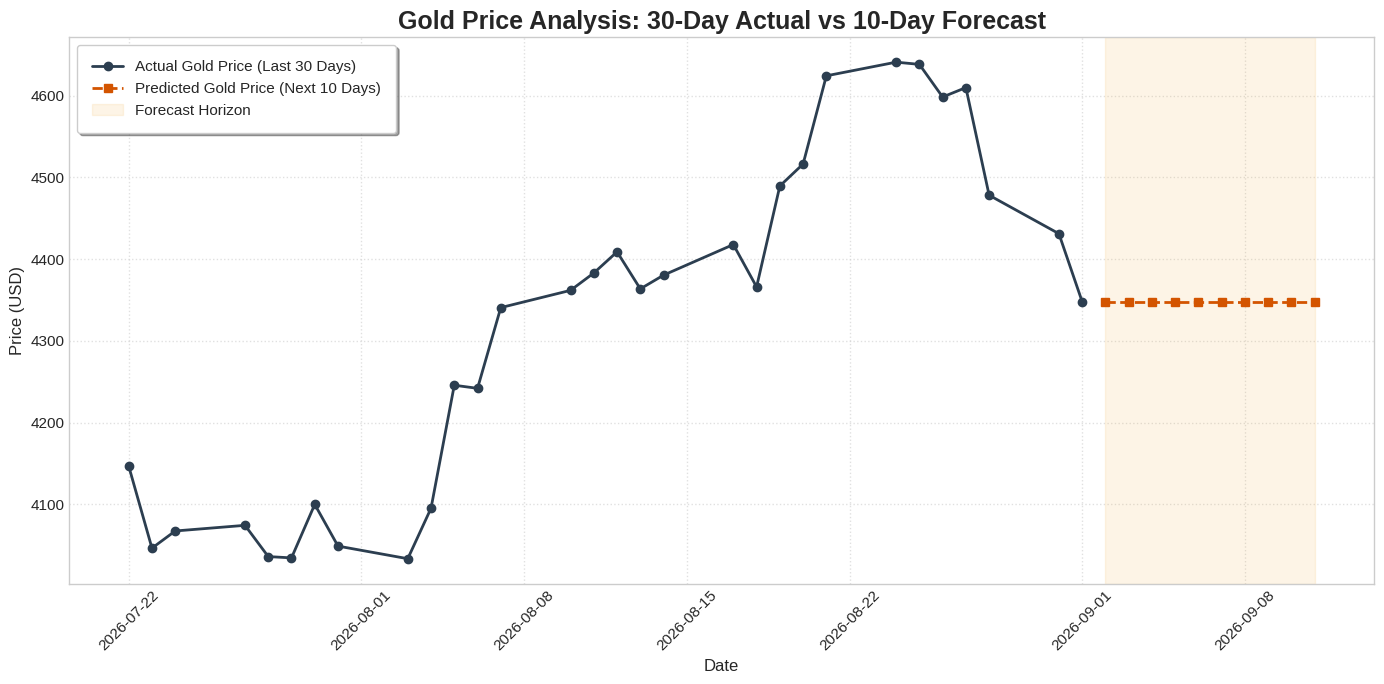

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

if 'Log_Close' not in df.columns:
    df['Log_Close'] = np.log(df['Close'])

actual_30 = df['Close'][-30:]

current_order = (0, 1, 0)
model_future = ARIMA(df['Log_Close'], order=current_order)
model_fit_future = model_future.fit()

forecast_log = model_fit_future.forecast(steps=10)
forecast_final = np.exp(forecast_log)

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10)

plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(actual_30.index, actual_30.values, color='#2c3e50', linewidth=2, marker='o', label='Actual Gold Price (Last 30 Days)')

plt.plot(future_dates, forecast_final, color='#d35400', linewidth=2, linestyle='--', marker='s', label='Predicted Gold Price (Next 10 Days)')

plt.axvspan(future_dates[0], future_dates[-1], color='#f39c12', alpha=0.1, label='Forecast Horizon')

plt.title('Gold Price Analysis: 30-Day Actual vs 10-Day Forecast', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.legend(loc='best', frameon=True, shadow=True, borderpad=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import pickle
import os
from google.colab import drive

# Tên file bạn muốn lưu
model_filename = 'gold_arima_model.pkl'

try:
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Lỗi kết nối Drive: {e}")

# 2. Thiết lập đường dẫn thư mục yêu cầu
target_dir = "/content/drive/MyDrive/CH ARIMA"
os.makedirs(target_dir, exist_ok=True)

# Đường dẫn đầy đủ để lưu vào Drive
full_path = os.path.join(target_dir, model_filename)

# Lưu mô hình vào file
with open(full_path, 'wb') as file:
    pickle.dump(final_model_fit, file)

print(f"Đã lưu mô hình thành công tại: {full_path}")
print("Bạn có thể kiểm tra trong thư mục 'CH ARIMA' trên Google Drive của mình.")

Mounted at /content/drive
Đã lưu mô hình thành công tại: /content/drive/MyDrive/CH ARIMA/gold_arima_model.pkl
Bạn có thể kiểm tra trong thư mục 'CH ARIMA' trên Google Drive của mình.
